In [56]:
import re
from io import StringIO
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

participants = ['Esben','Bert','Chris','Christiane','Seb']

def read_trials_csv(path):
    text = Path(path).read_text(encoding="utf-8")
    text = re.sub(r",(?=\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2},)", "\n", text)
    return pd.read_csv(StringIO(text))

items = pd.concat(
    [pd.read_csv(f"{p}_items.csv") for p in participants],
    ignore_index=True
)
trials = pd.concat(
    [read_trials_csv(f"{p}_trials.csv") for p in participants],
    ignore_index=True
)
items.drop(['chunk_label', 'timestamp','participant'], axis=1, inplace=True)

In [57]:
iex1 = items[(items["experiment"] == "free_recall") & (items["condition"] == "baseline")]
tex1 = trials[(trials["experiment"] == "free_recall") & (trials["condition"] == "baseline")]
iex2 = items[items["condition"] == "unfilled_delay"]
tex2 = trials[trials["condition"] == "unfilled_delay"]
iex3 = items[items["condition"] == "fast_rate"]
tex3 = trials[trials["condition"] == "fast_rate"]
iex4 = items[items["condition"] == "working_memory"]
tex4 = trials[trials["condition"] == "working_memory"]
iex5 = items[items["condition"].str.fullmatch(r"capacity_n\d")]
tex5 = trials[trials["condition"].str.fullmatch(r"capacity_n\d")]
iex6 = items[(items["experiment"] == "serial_recall") & (items["condition"] == "baseline")]
tex6 = trials[(trials["experiment"] == "serial_recall") & (trials["condition"] == "baseline")]
iex7 = items[items["condition"] == "finger_tapping"]
tex7 = trials[trials["condition"] == "finger_tapping"]
iex8 = items[items["condition"] == "articulatory_suppression"]
tex8 = trials[trials["condition"] == "articulatory_suppression"]
iex9 = items[items["condition"] == "real_idioms"]
tex9 = trials[trials["condition"] == "real_idioms"]
iex10 = items[items["condition"] == "fake_idioms"]
tex10 = trials[trials["condition"] == "fake_idioms"]


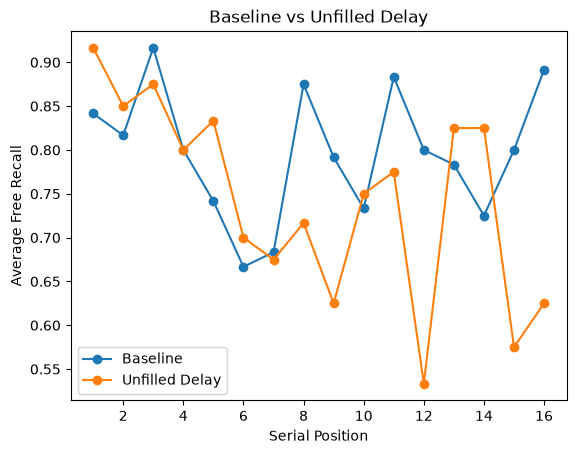

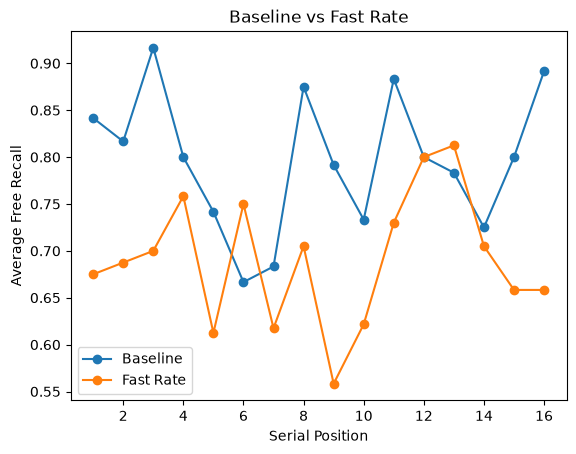

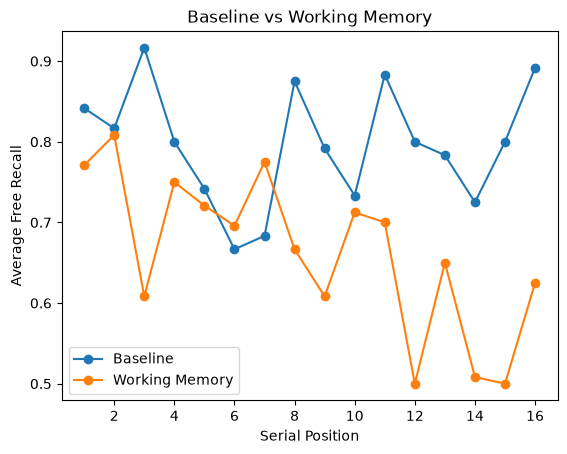

In [58]:
serial_curve1 = iex1.groupby("serial_position")["free_recalled"].mean()  # Baseline
serial_curve2 = iex2.groupby("serial_position")["free_recalled"].mean()  # Unfilled Delay
serial_curve3 = iex3.groupby("serial_position")["free_recalled"].mean()  # Fast Rate
serial_curve4 = iex4.groupby("serial_position")["free_recalled"].mean()  # Working Memory

# Graph 1: Baseline vs Unfilled Delay
plt.plot(serial_curve1.index, serial_curve1.values, marker="o", label="Baseline")
plt.plot(serial_curve2.index, serial_curve2.values, marker="o", label="Unfilled Delay")
plt.xlabel("Serial Position")
plt.ylabel("Average Free Recall")
plt.title("Baseline vs Unfilled Delay")
plt.legend()
plt.show()

# Graph 2: Baseline vs Fast Rate
plt.plot(serial_curve1.index, serial_curve1.values, marker="o", label="Baseline")
plt.plot(serial_curve3.index, serial_curve3.values, marker="o", label="Fast Rate")
plt.xlabel("Serial Position")
plt.ylabel("Average Free Recall")
plt.title("Baseline vs Fast Rate")
plt.legend()
plt.show()

# Graph 3: Baseline vs Working Memory
plt.plot(serial_curve1.index, serial_curve1.values, marker="o", label="Baseline")
plt.plot(serial_curve4.index, serial_curve4.values, marker="o", label="Working Memory")
plt.xlabel("Serial Position")
plt.ylabel("Average Free Recall")
plt.title("Baseline vs Working Memory")
plt.legend()
plt.show()

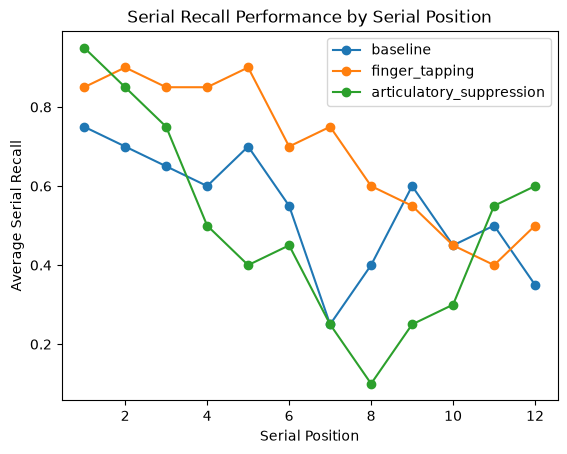

In [59]:
serial_curve6 = iex6.groupby("serial_position")["serial_correct"].mean()
serial_curve7 = iex7.groupby("serial_position")["serial_correct"].mean()
serial_curve8 = iex8.groupby("serial_position")["serial_correct"].mean()

plt.plot(serial_curve6.index, serial_curve6.values, marker="o", label="baseline")
plt.plot(serial_curve7.index, serial_curve7.values, marker="o", label="finger_tapping")
plt.plot(serial_curve8.index, serial_curve8.values, marker="o", label="articulatory_suppression")

plt.xlabel("Serial Position")
plt.ylabel("Average Serial Recall")
plt.title("Serial Recall Performance by Serial Position")
plt.legend()
plt.show()

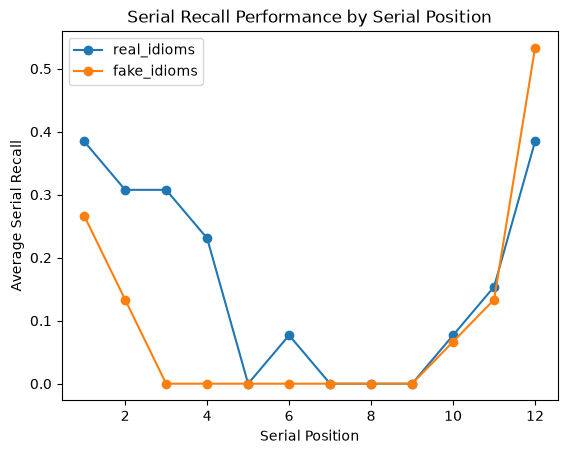

In [60]:
serial_curve9 = iex9.groupby("serial_position")["serial_correct"].mean()
serial_curve10 = iex10.groupby("serial_position")["serial_correct"].mean()

plt.plot(serial_curve9.index, serial_curve9.values, marker="o", label="real_idioms")
plt.plot(serial_curve10.index, serial_curve10.values, marker="o", label="fake_idioms")

plt.xlabel("Serial Position")
plt.ylabel("Average Serial Recall")
plt.title("Serial Recall Performance by Serial Position")
plt.legend()
plt.show()